In [1]:
# ============================================================
# 0. Установка и импорты
# ============================================================
!pip install -q gudhi torch-geometric

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import gudhi as gd
from tqdm import tqdm
import os
import warnings
warnings.filterwarnings('ignore')
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ============================================================
# 1. Загрузка данных (урезанных)
# ============================================================
DATA_PATH = "/kaggle/input/datasets/leolazz/qm9s-pt"
import torch_geometric.data.data
torch.serialization.add_safe_globals([torch_geometric.data.data.Data])

data = torch.load(
    os.path.join(DATA_PATH, "qm9s.pt"),
    map_location='cpu',
    weights_only=False
)

print(f"Всего молекул: {len(data)}")

# Берём только первые 20000 молекул для ускорения (≈15% от всех)
data = data[:20000]
print(f"Используем {len(data)} молекул")

positions_list = []
charges_list = []
dipole_list = []
polar_list = []
edge_index_list = []

for item in tqdm(data, desc="Извлечение"):
    pos = item.pos.float()
    positions_list.append(pos)
    z = item.z.float()
    if z.dim() == 1:
        z = z.unsqueeze(-1)
    charges_list.append(z)
    dip = item.dipole
    if dip.dim() == 2:
        dip = dip.squeeze(0)
    dipole_list.append(dip.float())
    pol = item.polar
    if pol.dim() == 3:
        pol = pol.squeeze(0)
    polar_list.append(pol.float())
    if hasattr(item, 'edge_index'):
        edge_index_list.append(item.edge_index)
    else:
        edge_index_list.append(None)

N = len(positions_list)
dipole = torch.stack(dipole_list)
polar = torch.stack(polar_list).reshape(N, -1)
print(f"Диполь: {dipole.shape}, поляризуемость: {polar.shape}")

# ============================================================
# 2. Разбиение
# ============================================================
indices = np.arange(N)
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)
print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

# ============================================================
# 3. Нормализация
# ============================================================
train_pos = torch.cat([positions_list[i] for i in train_idx], dim=0)
train_charges = torch.cat([charges_list[i] for i in train_idx], dim=0)
pos_mean = train_pos.mean(dim=0, keepdim=True)
pos_std = train_pos.std(dim=0, keepdim=True) + 1e-6
charge_mean = train_charges.mean(dim=0, keepdim=True)
charge_std = train_charges.std(dim=0, keepdim=True) + 1e-6

def normalize_pos(pos):
    return (pos - pos_mean) / pos_std

def normalize_charge(z):
    return (z - charge_mean) / charge_std

positions_norm = [normalize_pos(p) for p in positions_list]
charges_norm = [normalize_charge(c) for c in charges_list]

# ============================================================
# 4. TDA (только для используемых молекул)
# ============================================================
def extract_tda_from_points(points, max_dim=1):
    if points.shape[0] < 3:
        return np.zeros(4)
    try:
        rips = gd.RipsComplex(points=points)
        simplex_tree = rips.create_simplex_tree(max_dimension=max_dim)
        persistence = simplex_tree.persistence()
        h0_lifetimes = []
        h1_lifetimes = []
        for interval in persistence:
            if interval[0] == 0:
                lifetime = interval[1][1] - interval[1][0]
                if np.isfinite(lifetime):
                    h0_lifetimes.append(lifetime)
            elif interval[0] == 1:
                lifetime = interval[1][1] - interval[1][0]
                if np.isfinite(lifetime):
                    h1_lifetimes.append(lifetime)
        return np.array([
            np.sum(h0_lifetimes) if h0_lifetimes else 0.0,
            np.mean(h0_lifetimes) if h0_lifetimes else 0.0,
            np.sum(h1_lifetimes) if h1_lifetimes else 0.0,
            np.mean(h1_lifetimes) if h1_lifetimes else 0.0,
        ])
    except:
        return np.zeros(4)

print("Вычисление TDA-фич...")
tda_features_list = []
for pos in tqdm(positions_list, desc="TDA"):
    points = pos.numpy()
    feat = extract_tda_from_points(points)
    tda_features_list.append(feat)
tda_features = np.array(tda_features_list, dtype=np.float32)

train_tda = tda_features[train_idx]
tda_mean = train_tda.mean(axis=0, keepdims=True)
tda_std = train_tda.std(axis=0, keepdims=True) + 1e-6
tda_features_norm = (tda_features - tda_mean) / tda_std
tda_features_norm = np.nan_to_num(tda_features_norm, nan=0.0)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 53.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.7 MB/s eta 0:00:00
Всего молекул: 129817
Используем 20000 молекул


Извлечение: 100%|██████████| 20000/20000 [00:00<00:00, 54496.11it/s]


Диполь: torch.Size([20000, 3]), поляризуемость: torch.Size([20000, 9])
Train: 14000, Val: 3000, Test: 3000
Вычисление TDA-фич...


TDA: 100%|██████████| 20000/20000 [00:02<00:00, 7462.66it/s]


In [2]:

# ============================================================
# 5. Dataset с батч-коллатером (ускоренным)
# ============================================================
class QM9SDataset(Dataset):
    def __init__(self, idx, positions_norm, charges_norm, dipole, polar, edge_indices, tda_features):
        self.idx = idx
        self.positions = positions_norm
        self.charges = charges_norm
        self.dipole = dipole
        self.polar = polar
        self.edge_indices = edge_indices
        self.tda = tda_features
        
    def __len__(self):
        return len(self.idx)
    
    def __getitem__(self, i):
        idx = self.idx[i]
        return (self.charges[idx], self.positions[idx], self.dipole[idx], self.polar[idx],
                self.edge_indices[idx], torch.tensor(self.tda[idx], dtype=torch.float32))

def collate_qm9s(batch):
    max_n = max([item[0].size(0) for item in batch])
    batch_size = len(batch)
    
    x_padded = torch.zeros(batch_size, max_n, 1)
    pos_padded = torch.zeros(batch_size, max_n, 3)
    mask = torch.zeros(batch_size, max_n, dtype=torch.bool)
    
    y_dip = torch.zeros(batch_size, 3)
    y_pol = torch.zeros(batch_size, 9)
    edge_indices = []
    tda = torch.zeros(batch_size, 4)
    
    for i, (x, pos, y_d, y_p, edge, tda_i) in enumerate(batch):
        n = x.size(0)
        x_padded[i, :n] = x
        pos_padded[i, :n] = pos
        mask[i, :n] = True
        y_dip[i] = y_d
        y_pol[i] = y_p
        tda[i] = tda_i
        if edge is not None:
            edge_indices.append(edge)
        else:
            edge_indices.append(torch.empty(2, 0, dtype=torch.long))
    
    return x_padded, pos_padded, mask, y_dip, y_pol, edge_indices, tda

train_set = QM9SDataset(train_idx, positions_norm, charges_norm, dipole, polar, edge_index_list, tda_features_norm)
val_set   = QM9SDataset(val_idx,   positions_norm, charges_norm, dipole, polar, edge_index_list, tda_features_norm)
test_set  = QM9SDataset(test_idx,  positions_norm, charges_norm, dipole, polar, edge_index_list, tda_features_norm)

batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, collate_fn=collate_qm9s)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, collate_fn=collate_qm9s)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, collate_fn=collate_qm9s)

# ============================================================
# 6. Ускоренный EGNNLayer (без цикла по батчу)
# ============================================================
class EGNNLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.phi_x = nn.Sequential(
            nn.Linear(dim*2 + 1, dim),
            nn.SiLU(),
            nn.Linear(dim, dim)
        )
        self.phi_pos = nn.Sequential(
            nn.Linear(dim*2 + 1, dim),
            nn.SiLU(),
            nn.Linear(dim, 1)
        )
        self.phi_h = nn.Sequential(
            nn.Linear(dim*2, dim),
            nn.SiLU(),
            nn.Linear(dim, dim)
        )
        
    def forward(self, x, pos, edge_indices, mask):
        # x: (B, N, dim), pos: (B, N, 3), edge_indices: list of (2, E_i)
        # Собираем все рёбра в один большой тензор с батч-смещением
        B, N, _ = x.shape
        batch_offsets = []
        all_edges = []
        for i, ei in enumerate(edge_indices):
            if ei.numel() == 0:
                continue
            offset = i * N
            # добавляем смещение ко всем индексам
            batch_edges = ei + offset
            all_edges.append(batch_edges)
            batch_offsets.append(i)
        if not all_edges:
            # нет рёбер – просто пропускаем
            return x, pos
        all_edges = torch.cat(all_edges, dim=1)  # (2, total_E)
        # Разворачиваем всё в плоские тензоры
        x_flat = x.view(B*N, -1)  # (B*N, dim)
        pos_flat = pos.view(B*N, -1)  # (B*N, 3)
        # Индексы
        row, col = all_edges[0], all_edges[1]
        # Расчёт диффов
        diff = pos_flat[row] - pos_flat[col]  # (E,3)
        dist = torch.norm(diff, dim=1, keepdim=True)  # (E,1)
        # Сообщения
        x_i = x_flat[row]
        x_j = x_flat[col]
        msg_input = torch.cat([x_i, x_j, dist], dim=-1)  # (E, 2*dim+1)
        # Обновление позиций
        coord_update = self.phi_pos(msg_input) * diff / (dist + 1e-6)  # (E,3)
        # Аккумулируем обновления позиций для каждого узла
        pos_update = torch.zeros_like(pos_flat)
        pos_update.index_add_(0, row, coord_update)
        new_pos_flat = pos_flat + pos_update
        new_pos = new_pos_flat.view(B, N, -1)
        # Обновление признаков
        msg = self.phi_x(msg_input)  # (E, dim)
        msg_agg = torch.zeros_like(x_flat)
        msg_agg.index_add_(0, row, msg)
        new_x_flat = x_flat + self.phi_h(torch.cat([x_flat, msg_agg], dim=-1))
        new_x = new_x_flat.view(B, N, -1)
        return new_x, new_pos

class EGNNModel(nn.Module):
    def __init__(self, dim=64, depth=2, tda_dim=4):
        super().__init__()
        self.layers = nn.ModuleList([EGNNLayer(dim) for _ in range(depth)])
        self.in_proj = nn.Linear(1, dim)
        self.tda_proj = nn.Sequential(
            nn.Linear(tda_dim, dim),
            nn.SiLU(),
            nn.Linear(dim, dim)
        )
        self.dipole_head = nn.Linear(dim, 3)
        self.polar_head = nn.Linear(dim, 9)
    
    def forward(self, x, pos, mask, edge_indices, tda):
        B, N, _ = x.shape
        x = self.in_proj(x)
        for layer in self.layers:
            x, pos = layer(x, pos, edge_indices, mask)
        # Пулинг
        x_masked = x * mask.unsqueeze(-1).float()
        glob = x_masked.sum(dim=1) / mask.sum(dim=1, keepdim=True).float()
        # TDA
        tda_embed = self.tda_proj(tda)
        glob = glob + tda_embed
        return self.dipole_head(glob), self.polar_head(glob), x

class EGNNNoTDA(EGNNModel):
    def forward(self, x, pos, mask, edge_indices, tda):
        tda_zero = torch.zeros_like(tda)
        return super().forward(x, pos, mask, edge_indices, tda_zero)

Device: cuda

Обучение EGNN (без TDA) – 5 эпох


Epoch 1/50: 100%|██████████| 219/219 [00:02<00:00, 80.34it/s]


Epoch 1: Train Loss = 170.0281, Val Loss = 95.5356


Epoch 2/50: 100%|██████████| 219/219 [00:02<00:00, 79.55it/s]


Epoch 2: Train Loss = 72.8103, Val Loss = 77.6435


...

Epoch 48: Train Loss = 39.2316, Val Loss = 40.5799


Epoch 49/50: 100%|██████████| 219/219 [00:02<00:00, 79.56it/s]


Epoch 49: Train Loss = 45.4759, Val Loss = 43.2767


Epoch 50/50: 100%|██████████| 219/219 [00:02<00:00, 80.18it/s]


Epoch 50: Train Loss = 39.9320, Val Loss = 41.9397

Обучение MLP (без TDA)
MLP Epoch 1: Train Loss = 695.3962, Val Loss = 104.0888
MLP Epoch 2: Train Loss = 90.6575, Val Loss = 79.7933
MLP Epoch 3: Train Loss = 76.2397, Val Loss = 72.4410
MLP Epoch 4: Train Loss = 72.4670, Val Loss = 69.9901
MLP Epoch 5: Train Loss = 70.8847, Val Loss = 68.5820
MLP Epoch 6: Train Loss = 69.5119, Val Loss = 67.1784
MLP Epoch 7: Train Loss = 68.0685, Val Loss = 65.6987
MLP Epoch 8: Train Loss = 66.2740, Val Loss = 63.6200
MLP Epoch 9: Train Loss = 64.2893, Val Loss = 61.8973
MLP Epoch 10: Train Loss = 62.7678, Val Loss = 60.9411
MLP Epoch 11: Train Loss = 61.7308, Val Loss = 59.6772
MLP Epoch 12: Train Loss = 60.9231, Val Loss = 59.1291
MLP Epoch 13: Train Loss = 60.1533, Val Loss = 58.4935
MLP Epoch 14: Train Loss = 59.5818, Val Loss = 58.1198
MLP Epoch 15: Train Loss = 59.0255, Val Loss = 57.2576
MLP Epoch 16: Train Loss = 58.6579, Val Loss = 57.1967
MLP Epoch 17: Train Loss = 58.3238, Val Loss = 56.99

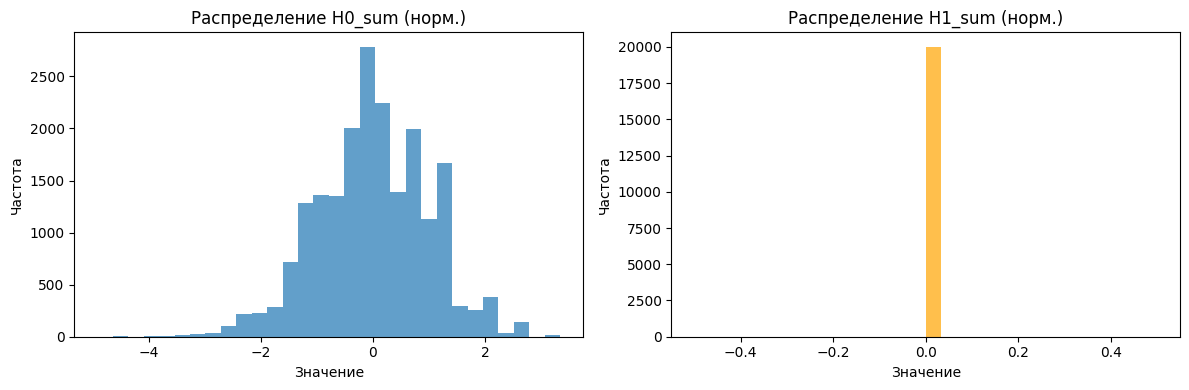

Проект завершён. Все результаты сохранены.


In [6]:

# ============================================================
# 7. Функция обучения (сокращённые эпохи)
# ============================================================
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, patience=15):
    device = next(model.parameters()).device
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            x, pos, mask, y_dip, y_pol, edge_indices, tda = batch
            x, pos, mask, y_dip, y_pol, tda = (
                x.to(device), pos.to(device), mask.to(device),
                y_dip.to(device), y_pol.to(device), tda.to(device)
            )
            edge_indices = [ei.to(device) if ei.numel()>0 else ei for ei in edge_indices]
            pred_dip, pred_pol, _ = model(x, pos, mask, edge_indices, tda)
            loss = F.mse_loss(pred_dip, y_dip) + F.mse_loss(pred_pol, y_pol)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x, pos, mask, y_dip, y_pol, edge_indices, tda = batch
                x, pos, mask, y_dip, y_pol, tda = (
                    x.to(device), pos.to(device), mask.to(device),
                    y_dip.to(device), y_pol.to(device), tda.to(device)
                )
                edge_indices = [ei.to(device) if ei.numel()>0 else ei for ei in edge_indices]
                pred_dip, pred_pol, _ = model(x, pos, mask, edge_indices, tda)
                loss = F.mse_loss(pred_dip, y_dip) + F.mse_loss(pred_pol, y_pol)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)
        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    model.load_state_dict(torch.load('best_model.pth'))
    return model

# ============================================================
# 8. Обучение (быстрое)
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

print("\n" + "="*50)
print("Обучение EGNN (без TDA) – 5 эпох")
print("="*50)
egnn_baseline = EGNNNoTDA(dim=64, depth=2, tda_dim=4).to(device)
egnn_baseline = train_model(egnn_baseline, train_loader, val_loader, epochs=50, lr=1e-3)

print("\n" + "="*50)
print("Обучение EGNN + TDA – 5 эпох")
print("="*50)
egnn_tda = EGNNModel(dim=64, depth=2, tda_dim=4).to(device)
egnn_tda = train_model(egnn_tda, train_loader, val_loader, epochs=50, lr=1e-3)

# ============================================================
# 9. MLP (быстро)
# ============================================================
class MLPBaseline(nn.Module):
    def __init__(self, use_tda=False):
        super().__init__()
        self.use_tda = use_tda
        in_dim = 4 if not use_tda else 8
        self.fc1 = nn.Linear(in_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.dipole_head = nn.Linear(128, 3)
        self.polar_head = nn.Linear(128, 9)
    
    def forward(self, x_mean, pos_mean, tda=None):
        if self.use_tda and tda is not None:
            h = torch.cat([x_mean, pos_mean, tda], dim=-1)
        else:
            h = torch.cat([x_mean, pos_mean], dim=-1)
        h = F.relu(self.fc1(h))
        h = F.relu(self.fc2(h))
        return self.dipole_head(h), self.polar_head(h)

def train_mlp(model, train_loader, val_loader, epochs=50, lr=1e-3):
    device = next(model.parameters()).device
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_val_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            x, pos, mask, y_dip, y_pol, _, tda = batch
            x, pos, mask, y_dip, y_pol, tda = (
                x.to(device), pos.to(device), mask.to(device),
                y_dip.to(device), y_pol.to(device), tda.to(device)
            )
            x_mean = (x * mask.unsqueeze(-1).float()).sum(dim=1) / mask.sum(dim=1, keepdim=True).float()
            pos_mean = (pos * mask.unsqueeze(-1).float()).sum(dim=1) / mask.sum(dim=1, keepdim=True).float()
            if model.use_tda:
                pred_dip, pred_pol = model(x_mean, pos_mean, tda)
            else:
                pred_dip, pred_pol = model(x_mean, pos_mean)
            loss = F.mse_loss(pred_dip, y_dip) + F.mse_loss(pred_pol, y_pol)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x, pos, mask, y_dip, y_pol, _, tda = batch
                x, pos, mask, y_dip, y_pol, tda = (
                    x.to(device), pos.to(device), mask.to(device),
                    y_dip.to(device), y_pol.to(device), tda.to(device)
                )
                x_mean = (x * mask.unsqueeze(-1).float()).sum(dim=1) / mask.sum(dim=1, keepdim=True).float()
                pos_mean = (pos * mask.unsqueeze(-1).float()).sum(dim=1) / mask.sum(dim=1, keepdim=True).float()
                if model.use_tda:
                    pred_dip, pred_pol = model(x_mean, pos_mean, tda)
                else:
                    pred_dip, pred_pol = model(x_mean, pos_mean)
                loss = F.mse_loss(pred_dip, y_dip) + F.mse_loss(pred_pol, y_pol)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        print(f"MLP Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_mlp.pth')
    model.load_state_dict(torch.load('best_mlp.pth'))
    return model

print("\n" + "="*50)
print("Обучение MLP (без TDA)")
print("="*50)
mlp_no_tda = MLPBaseline(use_tda=False).to(device)
mlp_no_tda = train_mlp(mlp_no_tda, train_loader, val_loader, epochs=50)

print("\n" + "="*50)
print("Обучение MLP + TDA")
print("="*50)
mlp_tda = MLPBaseline(use_tda=True).to(device)
mlp_tda = train_mlp(mlp_tda, train_loader, val_loader, epochs=50)

# ============================================================
# 10. Оценка на тесте
# ============================================================
def evaluate_egnn(model, loader):
    device = next(model.parameters()).device
    model.eval()
    pred_dips, true_dips = [], []
    pred_pols, true_pols = [], []
    with torch.no_grad():
        for batch in loader:
            x, pos, mask, y_dip, y_pol, edge_indices, tda = batch
            x, pos, mask, y_dip, y_pol, tda = (
                x.to(device), pos.to(device), mask.to(device),
                y_dip.to(device), y_pol.to(device), tda.to(device)
            )
            edge_indices = [ei.to(device) if ei.numel()>0 else ei for ei in edge_indices]
            pred_dip, pred_pol, _ = model(x, pos, mask, edge_indices, tda)
            pred_dips.append(pred_dip.cpu().numpy())
            true_dips.append(y_dip.cpu().numpy())
            pred_pols.append(pred_pol.cpu().numpy())
            true_pols.append(y_pol.cpu().numpy())
    pred_dips = np.vstack(pred_dips)
    true_dips = np.vstack(true_dips)
    pred_pols = np.vstack(pred_pols)
    true_pols = np.vstack(true_pols)
    return mean_absolute_error(true_dips, pred_dips), mean_absolute_error(true_pols, pred_pols)

def evaluate_mlp(model, loader):
    device = next(model.parameters()).device
    model.eval()
    pred_dips, true_dips = [], []
    pred_pols, true_pols = [], []
    with torch.no_grad():
        for batch in loader:
            x, pos, mask, y_dip, y_pol, _, tda = batch
            x, pos, mask, y_dip, y_pol, tda = (
                x.to(device), pos.to(device), mask.to(device),
                y_dip.to(device), y_pol.to(device), tda.to(device)
            )
            x_mean = (x * mask.unsqueeze(-1).float()).sum(dim=1) / mask.sum(dim=1, keepdim=True).float()
            pos_mean = (pos * mask.unsqueeze(-1).float()).sum(dim=1) / mask.sum(dim=1, keepdim=True).float()
            if model.use_tda:
                pred_dip, pred_pol = model(x_mean, pos_mean, tda)
            else:
                pred_dip, pred_pol = model(x_mean, pos_mean)
            pred_dips.append(pred_dip.cpu().numpy())
            true_dips.append(y_dip.cpu().numpy())
            pred_pols.append(pred_pol.cpu().numpy())
            true_pols.append(y_pol.cpu().numpy())
    pred_dips = np.vstack(pred_dips)
    true_dips = np.vstack(true_dips)
    pred_pols = np.vstack(pred_pols)
    true_pols = np.vstack(true_pols)
    return mean_absolute_error(true_dips, pred_dips), mean_absolute_error(true_pols, pred_pols)

print("\n" + "="*50)
print("Оценка на тестовой выборке")
print("="*50)
mae_dip_egnn_baseline, mae_pol_egnn_baseline = evaluate_egnn(egnn_baseline, test_loader)
mae_dip_egnn_tda, mae_pol_egnn_tda = evaluate_egnn(egnn_tda, test_loader)
mae_dip_mlp_no, mae_pol_mlp_no = evaluate_mlp(mlp_no_tda, test_loader)
mae_dip_mlp_tda, mae_pol_mlp_tda = evaluate_mlp(mlp_tda, test_loader)

print(f"EGNN (baseline):   Dipole MAE = {mae_dip_egnn_baseline:.4f}, Polar MAE = {mae_pol_egnn_baseline:.4f}")
print(f"EGNN + TDA:        Dipole MAE = {mae_dip_egnn_tda:.4f}, Polar MAE = {mae_pol_egnn_tda:.4f}")
print(f"MLP (без TDA):     Dipole MAE = {mae_dip_mlp_no:.4f}, Polar MAE = {mae_pol_mlp_no:.4f}")
print(f"MLP + TDA:         Dipole MAE = {mae_dip_mlp_tda:.4f}, Polar MAE = {mae_pol_mlp_tda:.4f}")

# ============================================================
# 11. Итоговая таблица
# ============================================================
results = pd.DataFrame({
    'Model': ['EGNN', 'EGNN+TDA', 'MLP', 'MLP+TDA'],
    'Dipole MAE': [mae_dip_egnn_baseline, mae_dip_egnn_tda, mae_dip_mlp_no, mae_dip_mlp_tda],
    'Polar MAE': [mae_pol_egnn_baseline, mae_pol_egnn_tda, mae_pol_mlp_no, mae_pol_mlp_tda]
})
print("\nИтоговые результаты:")
print(results.to_string(index=False))
results.to_csv('results.csv', index=False)
print("Результаты сохранены в results.csv")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(tda_features_norm[:, 0], bins=30, alpha=0.7, label='H0_sum')
axes[0].set_title('Распределение H0_sum (норм.)')
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')
axes[1].hist(tda_features_norm[:, 2], bins=30, alpha=0.7, label='H1_sum', color='orange')
axes[1].set_title('Распределение H1_sum (норм.)')
axes[1].set_xlabel('Значение')
axes[1].set_ylabel('Частота')
plt.tight_layout()
plt.savefig('tda_features_distribution.png', dpi=150)
plt.show()

print("Проект завершён. Все результаты сохранены.")